Diabetes 30-Day Readmission


In [23]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.pandas.set_option('display.max_columns', None)

df = pd.read_csv("diabetic_data.csv")
ids_map = pd.read_csv("IDS_mapping.csv")
print(df.shape)


(101766, 50)


In [25]:
#Standardizing missing value
df = df.replace('?', np.nan)
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(10))


weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
patient_nbr           0.000000
dtype: float64


In [26]:
#Dropping missing columns
df = df.drop(columns=['weight','payer_code','medical_specialty'])
print(df.shape)


(101766, 47)


In [29]:
if 'encounter_id' in df.columns:
    df = df.drop(columns=['encounter_id'])
print('There are', df['patient_nbr'].nunique(), 'unique patients out of a total of', len(df), 'rows.')

There are 71518 unique patients out of a total of 101766 rows.


In [30]:
df['race'] = df['race'].fillna(df['race'].mode()[0])
df['gender'] = df['gender'].replace('Unknown/Invalid', np.nan)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
print(df['race'].value_counts())
print(df['gender'].value_counts())


race
Caucasian          78372
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
gender
Female    54711
Male      47055
Name: count, dtype: int64


In [31]:
age_map = {'[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,'[40-50)':45,
           '[50-60)':55,'[60-70)':65,'[70-80)':75,'[80-90)':85,'[90-100)':95}
df['age'] = df['age'].replace(age_map).astype(int)
print(df['age'].dtype)
df['age'].value_counts().sort_index()


int64


,count
age,
5,161
15,691
25,1657
35,3775
45,9685
55,17256
65,22483
75,26068
85,17197


In [35]:
df['admission_type_id'] = df['admission_type_id'].replace({
    1:'Emergency', 2:'Urgent', 7:'Trauma Center',
    5:'Not Available', 6:'Not Available', 8:'Not Available',
    3:'Elective', 4:'Newborn'})

#Dropping newborn admissions
before = len(df)
df = df[df['admission_type_id'] != 'Newborn']
df['admission_type_id'].value_counts()


,count
admission_type_id,
Emergency,53990
Elective,18869
Urgent,18480
Not Available,10396
Trauma Center,21


In [39]:
exclude_codes = [11, 13, 14, 19, 20, 21]  # expired or hospice -- confirmed against IDS_mapping.csv
before = len(df)
df = df[~df['discharge_disposition_id'].isin(exclude_codes)]

#Dropping deceased/hospice
def map_discharge(code):
    if code == 1: return 'Home'
    if code in [6, 8]: return 'Home_with_care'
    if code in [2, 3, 4, 5, 9, 10, 15, 22, 23, 24, 27, 28, 29, 30]: return 'Transferred_facility'
    if code == 7: return 'Left_AMA'
    return 'Other'

df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(map_discharge)
df['discharge_disposition_id'].value_counts()


,count
discharge_disposition_id,
Other,99333


In [40]:
def map_admission_source(code):
    if code in [1, 2, 3]: return 'Referral'
    if code in [4, 5, 6, 10, 18, 22, 25, 26]: return 'Transfer'
    if code == 7: return 'Emergency'
    if code in [11, 12, 13, 14, 23, 24]: return 'Delivery_Birth'
    return 'Other'

df['admission_source_id'] = df['admission_source_id'].apply(map_admission_source)
df['admission_source_id'].value_counts()


,count
admission_source_id,
Emergency,55848
Referral,30432
Other,6869
Transfer,6180
Delivery_Birth,4


In [41]:
def map_diag(code):
    if pd.isna(code):
        return 'Missing'
    try:
        code = float(code)
    except ValueError:
        return 'Other'   # V- and E- codes (external causes / supplementary classification)
    if 390 <= code <= 459 or code == 785: return 'Circulatory'
    if 460 <= code <= 519 or code == 786: return 'Respiratory'
    if 520 <= code <= 579 or code == 787: return 'Digestive'
    if 250 <= code < 251: return 'Diabetes'
    if 800 <= code <= 999: return 'Injury'
    if 710 <= code <= 739: return 'Musculoskeletal'
    if 580 <= code <= 629 or code == 788: return 'Genitourinary'
    if 140 <= code <= 239: return 'Neoplasms'
    if 240 <= code <= 279: return 'Endocrine_other'
    return 'Other'

for c in ['diag_1', 'diag_2', 'diag_3']:
    df[c + '_group'] = df[c].apply(map_diag)

df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])
df['diag_1_group'].value_counts()


,count
diag_1_group,
Circulatory,29678
Other,15150
Respiratory,13932
Digestive,9332
Diabetes,8660
Injury,6852
Genitourinary,5002
Musculoskeletal,4934
Neoplasms,3131


In [42]:
df['service_utilization'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df[['number_outpatient','number_emergency','number_inpatient','service_utilization']].describe()


,number_outpatient,number_emergency,number_inpatient,service_utilization
count,99333.000000,99333.000000,99333.000000,99333.000000
mean,0.369253,0.198464,0.630989,1.198705
std,1.265174,0.937779,1.260477,2.294298
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,2.000000
max,42.000000,76.000000,21.000000,80.000000


In [43]:
df['max_glu_serum'] = df['max_glu_serum'].map({'Norm':1, '>200':2, '>300':3}).fillna(0)
df['A1Cresult'] = df['A1Cresult'].map({'Norm':1, '>7':2, '>8':3}).fillna(0)
print(df['max_glu_serum'].value_counts())
print(df['A1Cresult'].value_counts())


max_glu_serum
0.0    94181
1.0     2545
2.0     1419
3.0     1188
Name: count, dtype: int64
A1Cresult
0.0    82501
3.0     8137
1.0     4922
2.0     3773
Name: count, dtype: int64


In [44]:
df['gender'] = df['gender'].map({'Female':0, 'Male':1})
df['change'] = df['change'].map({'No':0, 'Ch':1})
df['diabetesMed'] = df['diabetesMed'].map({'No':0, 'Yes':1})


In [45]:
near_constant = ['examide','citoglipton','acetohexamide','glimepiride-pioglitazone',
                  'metformin-rosiglitazone','metformin-pioglitazone','troglitazone',
                  'tolbutamide','glipizide-metformin']
df = df.drop(columns=near_constant)

drug_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
             'glipizide','glyburide','pioglitazone','rosiglitazone','acarbose',
             'miglitol','tolazamide','insulin','glyburide-metformin']
ordinal_map = {'No':0, 'Down':1, 'Steady':2, 'Up':3}
for c in drug_cols:
    df[c] = df[c].map(ordinal_map)

print(df[drug_cols].describe().T[['mean','std']])


                         mean       std
metformin            0.404448  0.819542
repaglinide          0.031208  0.253459
nateglinide          0.014003  0.168597
chlorpropamide       0.001762  0.060758
glimepiride          0.104427  0.453599
glipizide            0.254477  0.679528
glyburide            0.214299  0.633429
pioglitazone         0.147192  0.527721
rosiglitazone        0.127792  0.493523
acarbose             0.006211  0.112500
miglitol             0.000735  0.038462
tolazamide           0.000795  0.040252
insulin              1.056990  1.099399
glyburide-metformin  0.014054  0.167605


In [47]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_30'].value_counts())
print('Positive rate:', df['readmitted_30'].mean().round(4))


readmitted_30
0    88020
1    11313
Name: count, dtype: int64
Positive rate: 0.1139


In [50]:
df.shape
print('\nRemaining non-numeric columns')
print(df.select_dtypes(include='object').columns.tolist())

print('\nMissing values left:')
print(df.isnull().sum()[df.isnull().sum() > 0])

df.to_pickle('cleaned_diabetic_data.pkl')


Remaining non-numeric columns
['race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'readmitted', 'diag_1_group', 'diag_2_group', 'diag_3_group']

Missing values left:
Series([], dtype: int64)


In [53]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, pointbiserialr

df = pd.read_pickle('cleaned_diabetic_data.pkl')
target = 'readmitted_30'

exclude_from_analysis = ['patient_nbr', 'readmitted', target]

cat_cols = [c for c in df.select_dtypes(include='object').columns if c not in exclude_from_analysis]
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns if c not in exclude_from_analysis]

print('Categorical columns being tested:', cat_cols)
print('Numeric columns being tested:', num_cols)


Categorical columns being tested: ['race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Numeric columns being tested: ['gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'service_utilization']


In [54]:
#Categorical features vs. target
results_cat = []
for c in cat_cols:
    table = pd.crosstab(df[c], df[target])
    chi2, p, dof, exp = chi2_contingency(table)
    n = table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    results_cat.append((c, p, cramers_v))

res_cat_df = pd.DataFrame(results_cat, columns=['feature','p_value','cramers_v'])
res_cat_df = res_cat_df.sort_values('cramers_v', ascending=False).reset_index(drop=True)
res_cat_df


,feature,p_value,cramers_v
0,diag_3_group,1.990257e-24,0.037098
1,diag_1_group,2.793406e-14,0.029488
2,diag_2_group,1.188898e-11,0.027100
3,admission_source_id,1.695129e-09,0.021701
4,admission_type_id,4.954051e-06,0.017371
5,race,1.879132e-01,0.007871
6,discharge_disposition_id,1.000000e+00,NaN


In [55]:
#Numeric features vs. target
results_num = []
for c in num_cols:
    r, p = pointbiserialr(df[target], df[c])
    results_num.append((c, p, r))

res_num_df = pd.DataFrame(results_num, columns=['feature','p_value','correlation'])
res_num_df['abs_corr'] = res_num_df['correlation'].abs()
res_num_df = res_num_df.sort_values('abs_corr', ascending=False).drop(columns='abs_corr').reset_index(drop=True)
res_num_df


,feature,p_value,correlation
0,number_inpatient,0.000000e+00,0.168337
1,service_utilization,0.000000e+00,0.127946
2,number_emergency,3.210450e-82,0.060887
3,number_diagnoses,5.369996e-64,0.053551
4,time_in_hospital,1.712437e-49,0.046900
5,num_medications,1.396699e-38,0.041198
6,insulin,1.391227e-18,0.027910
7,metformin,1.087612e-16,-0.026314
8,diabetesMed,2.840364e-16,0.025950
9,num_lab_procedures,3.365251e-14,0.024058


In [56]:
drop_weak = ['race', 'gender', 'tolazamide', 'miglitol', 'glipizide',
             'glyburide-metformin', 'nateglinide', 'acarbose', 'chlorpropamide']

df_model = df.drop(columns=drop_weak)
print('Dropped (negligible effect size, non-significant):', drop_weak)
print('Remaining shape:', df_model.shape)


Dropped (negligible effect size, non-significant): ['race', 'gender', 'tolazamide', 'miglitol', 'glipizide', 'glyburide-metformin', 'nateglinide', 'acarbose', 'chlorpropamide']
Remaining shape: (99333, 30)


In [57]:
cat_cols_remaining = df_model.select_dtypes(include='object').columns.tolist()
cat_cols_remaining = [c for c in cat_cols_remaining if c != 'readmitted']
print('One-hot encoding:', cat_cols_remaining)

df_encoded = pd.get_dummies(df_model, columns=cat_cols_remaining, drop_first=True)
df_encoded = df_encoded.drop(columns=['readmitted'])
print('Final feature matrix shape (including patient_nbr and target):', df_encoded.shape)


One-hot encoding: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Final feature matrix shape (including patient_nbr and target): (99333, 61)


In [58]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = df_encoded['patient_nbr']
train_idx, test_idx = next(gss.split(df_encoded, groups=groups))

train_df = df_encoded.iloc[train_idx]
test_df = df_encoded.iloc[test_idx]

overlap = set(train_df['patient_nbr']) & set(test_df['patient_nbr'])
print('Patient overlap between train and test (must be 0):', len(overlap))

target = 'readmitted_30'
X_train = train_df.drop(columns=['patient_nbr', target])
y_train = train_df[target]
X_test = test_df.drop(columns=['patient_nbr', target])
y_test = test_df[target]

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train positive rate: %.4f   Test positive rate: %.4f' % (y_train.mean(), y_test.mean()))


Patient overlap between train and test (must be 0): 0
Train shape: (79434, 59)  Test shape: (19899, 59)
Train positive rate: 0.1146   Test positive rate: 0.1109


Training Models

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

results = {}

# Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=2000)
log_reg.fit(X_train_scaled, y_train)
proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
results['LogReg'] = (roc_auc_score(y_test, proba_lr), average_precision_score(y_test, proba_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
results['RandomForest'] = (roc_auc_score(y_test, proba_rf), average_precision_score(y_test, proba_rf))

# XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(scale_pos_weight=neg/pos, eval_metric='logloss',
                               max_depth=5, n_estimators=200, learning_rate=0.1,
                               random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
results['XGBoost'] = (roc_auc_score(y_test, proba_xgb), average_precision_score(y_test, proba_xgb))

print('Model comparison:')
print(f"{'Model':15s} {'AUC':>8s} {'PR-AUC':>8s}")
for k, v in results.items():
    print(f"{k:15s} {v[0]:8.4f} {v[1]:8.4f}")


Model comparison:
Model                AUC   PR-AUC
LogReg            0.6372   0.2010
RandomForest      0.6322   0.1844
XGBoost           0.6340   0.1910


In [60]:
best_proba = proba_xgb
best_model = xgb_model

print(classification_report(y_test, (best_proba > 0.5).astype(int)))
print('Confusion matrix (threshold = 0.5):')
print(confusion_matrix(y_test, (best_proba > 0.5).astype(int)))


              precision    recall  f1-score   support

           0       0.92      0.66      0.76     17693
           1       0.16      0.52      0.24      2206

    accuracy                           0.64     19899
   macro avg       0.54      0.59      0.50     19899
weighted avg       0.83      0.64      0.71     19899

Confusion matrix (threshold = 0.5):
[[11590  6103]
 [ 1051  1155]]


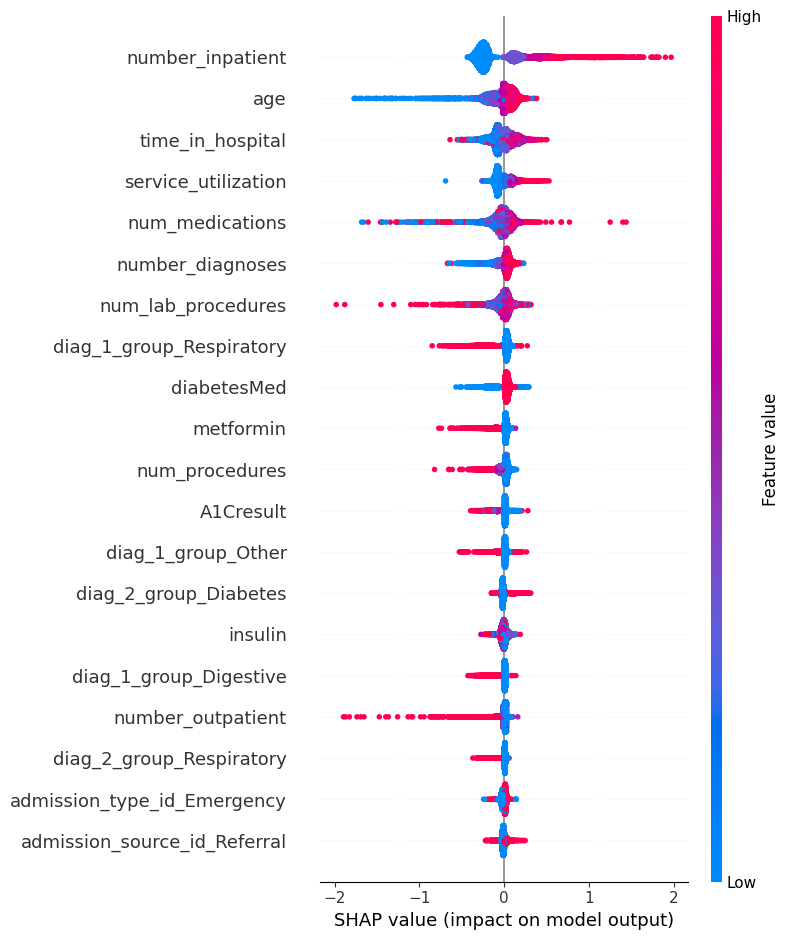

In [61]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()


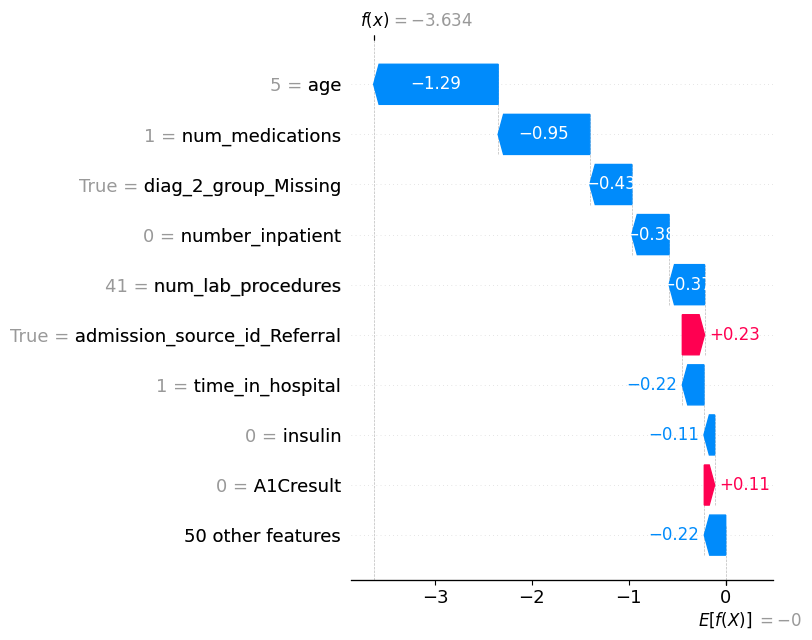

In [62]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
), show=False)
plt.tight_layout()
plt.show()
